# 04 · EDA — Lluvia por masa subterranea

`gold.lluvia_masa_subterranea` — precipitacion mensual (mm) por masa, fusion AEMET + Open-Meteo. Feature candidata: lluvia anual por municipio (media de las masas del municipio).


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "lluvia_masa_subterranea.csv", infer_schema_length=None)
print("shape:", df.shape)
print("masas:", df["cod_masa"].n_unique())
df.head(5)


shape: (11867, 5)
masas: 87


cod_masa,anio,mes,precipitacion_mm,fuente
str,i64,i64,f64,str
"""1806M1""",2021,6,34.5,"""aemet"""
"""1815M2""",2016,9,68.5,"""aemet"""
"""1814M4""",2024,6,20.0,"""aemet"""
"""1804M2""",2018,7,18.8,"""aemet"""
"""1821M2""",2016,7,0.0,"""aemet"""


In [3]:
print("Nulos por columna:")
df.null_count()
print("fuentes:", df.group_by("fuente").len())


Nulos por columna:
fuentes: shape: (2, 2)
┌───────────┬──────┐
│ fuente    ┆ len  │
│ ---       ┆ ---  │
│ str       ┆ u32  │
╞═══════════╪══════╡
│ openmeteo ┆ 6255 │
│ aemet     ┆ 5612 │
└───────────┴──────┘


In [4]:
# Cobertura temporal por masa
cov = df.group_by("cod_masa").agg(anio_min=pl.col("anio").min(), anio_max=pl.col("anio").max(), n=pl.len())
print("masas con serie completa 2015-2026 (144 meses):", cov.filter(pl.col("n") == 144).height, "de", cov.height)
cov.sort("n").head(5)


masas con serie completa 2015-2026 (144 meses): 0 de 87


cod_masa,anio_min,anio_max,n
str,i64,i64,u32
"""1815M1""",2015,2022,91
"""1815M2""",2015,2022,91
"""2002M2""",2018,2026,97
"""2002M3""",2018,2026,97
"""1901M2""",2015,2026,123


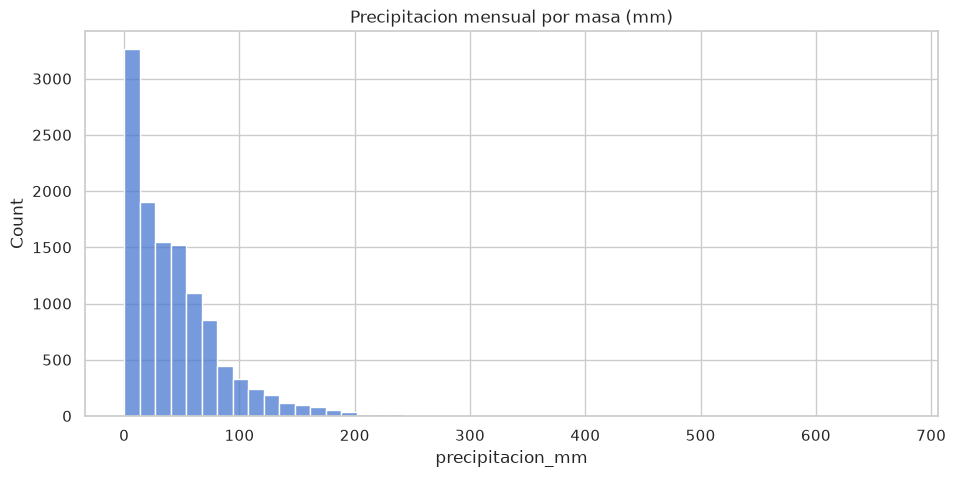

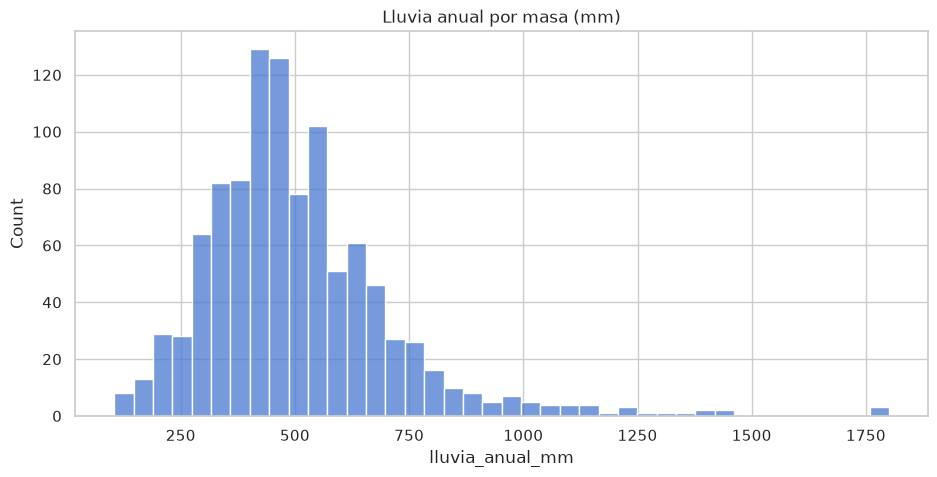

In [5]:
# Distribucion de la precipitacion mensual y anual por masa
sns.histplot(df["precipitacion_mm"].to_pandas(), bins=50)
plt.title("Precipitacion mensual por masa (mm)")
plt.show()

anual = df.group_by(["cod_masa", "anio"]).agg(pl.col("precipitacion_mm").sum().alias("lluvia_anual_mm"))
sns.histplot(anual["lluvia_anual_mm"].to_pandas(), bins=40)
plt.title("Lluvia anual por masa (mm)")
plt.show()


municipios cubiertos por lluvia municipal: 66 de 67
sin cobertura (se imputan con la media): [7024]


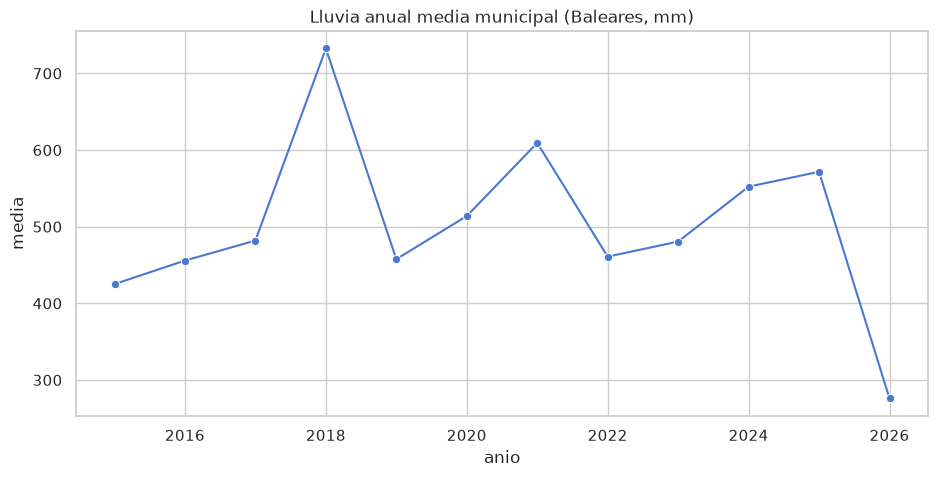

In [6]:
# Feature municipal: lluvia anual media de las masas del municipio
mma = pl.read_csv(DATA / "municipio_masa_subterranea.csv", infer_schema_length=None)
ll_mun = (anual.join(mma, on="cod_masa")
          .group_by(["cod_municipio", "anio"])
          .agg(pl.col("lluvia_anual_mm").mean().alias("lluvia_anual_mm")))

mun = pl.read_csv(DATA / "municipio.csv", infer_schema_length=None)
sin_lluvia = mun.filter(~pl.col("cod_municipio").is_in(ll_mun["cod_municipio"].unique().to_list()))
print(f"municipios cubiertos por lluvia municipal: {ll_mun['cod_municipio'].n_unique()} de {mun.height}")
print("sin cobertura (se imputan con la media):", sin_lluvia["cod_municipio"].to_list())

sns.lineplot(data=ll_mun.group_by("anio").agg(pl.col("lluvia_anual_mm").mean().alias("media")).to_pandas(), x="anio", y="media", marker="o")
plt.title("Lluvia anual media municipal (Baleares, mm)")
plt.show()


**Conclusiones EDA**

- 87 masas con lluvia mensual 2015-2026; las 3 sin coeficientes de infiltracion (1902M1, 1903M1, 1903M2) si tienen lluvia.
- Fuentes fusionadas: Open-Meteo (masas sin estacion AEMET) + AEMET.
- Feature: `lluvia_anual_mm` por municipio = media de la lluvia anual de sus masas. Solo `07024` (Palma tiene varias masas, verificar) queda sin mapping -> imputar media global.
